## ANN

In [64]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/전처리완료.csv")

In [66]:
# 데이터 분리 라이브러리
from sklearn.model_selection import train_test_split

# 특징 변수(X)와 목표 변수(y) 분리
X = df.drop('고객이탈여부', axis=1)
y = df['고객이탈여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
# ANN 모델 생성
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))  # 입력층
model.add(Dense(32, activation='relu'))  # 은닉층
model.add(Dense(1, activation='sigmoid'))  # 출력층 (이진 분류를 위한 시그모이드 활성화)

In [68]:
# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [69]:
# 모델 훈련
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# 모델 평가
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Epoch 1/50
250/250 [==============================] - 1s 1ms/step - loss: 753.1143 - accuracy: 0.6706 - val_loss: 112.3980 - val_accuracy: 0.3635
Epoch 2/50
250/250 [==============================] - 0s 861us/step - loss: 140.4463 - accuracy: 0.6760 - val_loss: 117.1924 - val_accuracy: 0.7195
Epoch 3/50
250/250 [==============================] - 0s 765us/step - loss: 107.6104 - accuracy: 0.6777 - val_loss: 75.8989 - val_accuracy: 0.7315
Epoch 4/50
250/250 [==============================] - 0s 861us/step - loss: 146.1917 - accuracy: 0.6802 - val_loss: 160.2820 - val_accuracy: 0.5560
Epoch 5/50
250/250 [==============================] - 0s 955us/step - loss: 101.1414 - accuracy: 0.6815 - val_loss: 76.3199 - val_accuracy: 0.5380
Epoch 6/50
250/250 [==============================] - 0s 713us/step - loss: 134.3037 - accuracy: 0.6799 - val_loss: 67.7891 - val_accuracy: 0.5270
Epoch 7/50
250/250 [==============================] - 0s 917us/step - loss: 114.7615 - accuracy: 0.6817 - val_loss: 9

In [70]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score
# 예측값 생성
y_pred_proba = model.predict(X_test)  # 예측 확률값
y_pred = (y_pred_proba > 0.5).astype(int)  # 0.5를 기준으로 이진 분류

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



63/63 [==============================] - 0s 426us/step
Accuracy: 0.788
Precision: 0.3697478991596639
Recall 0.11195928753180662
f1_score 0.17187500000000003
Confusion Matrix:
 [[1532   75]
 [ 349   44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.88      1607
           1       0.37      0.11      0.17       393

    accuracy                           0.79      2000
   macro avg       0.59      0.53      0.53      2000
weighted avg       0.73      0.79      0.74      2000



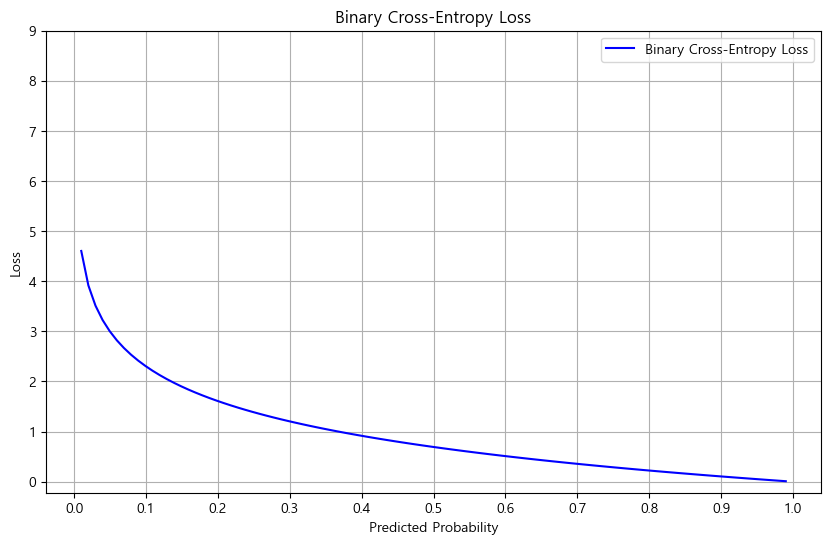

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# 이진 크로스 엔트로피 함수 정의
def binary_cross_entropy(y_true, y_pred):
    return - (y_true * np.log(y_pred + 1e-10) + (1 - y_true) * np.log(1 - y_pred + 1e-10))

# 예측 확률과 실제 값 설정
y_true = 1  # 실제 클래스
y_pred = np.linspace(0.01, 0.99, 100)  # 0.01부터 0.99까지의 예측 확률

# 손실 계산
loss = binary_cross_entropy(y_true, y_pred)

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(y_pred, loss, label='Binary Cross-Entropy Loss', color='blue')
plt.title('Binary Cross-Entropy Loss')
plt.xlabel('Predicted Probability')
plt.ylabel('Loss')
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 10, 1))
plt.grid()
plt.legend()
plt.show()


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# 한글포트 출력
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 삼성전자, KOSPI 데이터 불러오기
stock_price = yf.download({'005930.KS','^KS11'}, '2021-01-01', '2023-12-31')

# 수정종가 데이터 가져오기
df = stock_price['Adj Close']

# 수익률 데이터로 변경하기
df = stock_price["Adj Close"].pct_change()*100
df = df.dropna()

[*********************100%%**********************]  2 of 2 completed


In [84]:
df

,005930.KS,^KS11
Date,,
2021-01-05,1.084351,1.566341
2021-01-06,-2.026234,-0.747687
2021-01-07,0.851565,2.138325
2021-01-08,7.117037,3.974694
2021-01-11,2.477474,-0.118330
...,...,...
2023-12-21,0.267364,-0.546228
2023-12-22,1.200004,-0.019616
2023-12-26,0.922265,0.118487


In [85]:
X = df[["005930.KS"]]
y = df[["^KS11"]]

In [86]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:

# ANN 모델 생성
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))  # 입력층
model.add(Dense(32, activation='relu'))  # 은닉층
model.add(Dense(1))  # 출력층 (회귀 문제이므로 활성화 함수 없음)

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련 및 손실 값 기록
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)
# 예측
y_pred = model.predict(X_test)

Epoch 1/100
15/15 [==============================] - 1s 7ms/step - loss: 1.0014 - val_loss: 0.6260
Epoch 2/100
15/15 [==============================] - 0s 2ms/step - loss: 0.7197 - val_loss: 0.4902
Epoch 3/100
15/15 [==============================] - 0s 8ms/step - loss: 0.5671 - val_loss: 0.4312
Epoch 4/100
15/15 [==============================] - 0s 4ms/step - loss: 0.5170 - val_loss: 0.4149
Epoch 5/100
15/15 [==============================] - 0s 3ms/step - loss: 0.5026 - val_loss: 0.4148
Epoch 6/100
15/15 [==============================] - 0s 8ms/step - loss: 0.5017 - val_loss: 0.4165
Epoch 7/100
15/15 [==============================] - 0s 7ms/step - loss: 0.4976 - val_loss: 0.4172
Epoch 8/100
15/15 [==============================] - 0s 4ms/step - loss: 0.4967 - val_loss: 0.4181
Epoch 9/100
15/15 [==============================] - 0s 3ms/step - loss: 0.4985 - val_loss: 0.4191
Epoch 10/100
15/15 [==============================] - 0s 2ms/step - loss: 0.4956 - val_loss: 0.4204
Epoch 11/

5/5 [==============================] - 0s 747us/step
Mean Squared Error: 0.5035


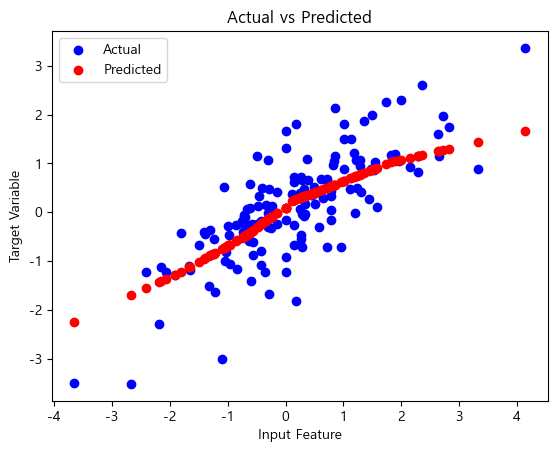

In [88]:
from sklearn.metrics import mean_squared_error
# 예측
y_pred = model.predict(X_test)

# MSE 계산
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.4f}')

# 결과 시각화
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted')
plt.xlabel('Input Feature')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

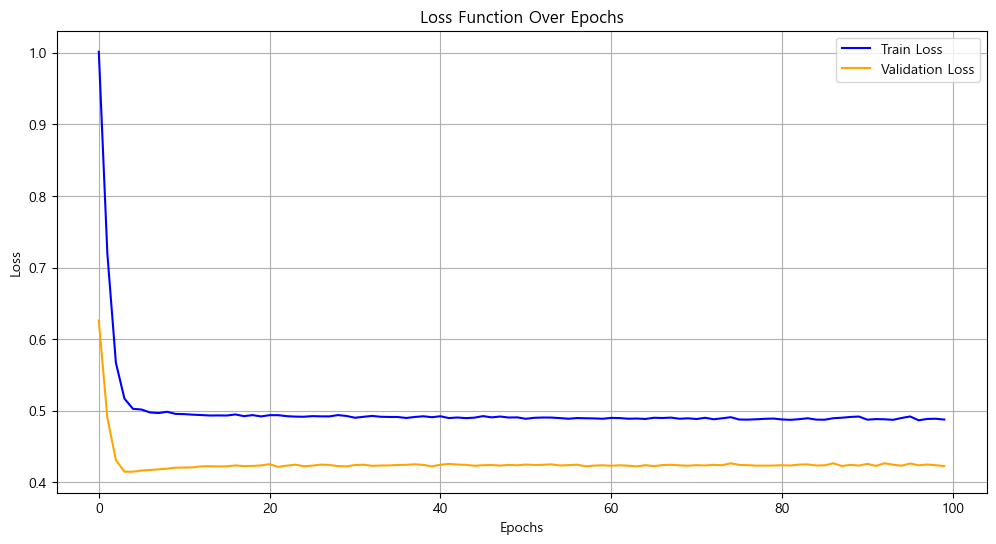

In [89]:
# 손실 함수 그래프
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss Function Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()